<a href="https://colab.research.google.com/github/Shan-Arangodan/Diabetes-Prediction-Using-Machine-Learning/blob/main/projectttt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [ ]:
import pandas as pd
df= pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# data = pd.read_csv(f'{jamaltariqcheema_pima_indians_diabetes_dataset_path}/diabetes.csv')
data = df
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [ ]:
data.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
data.shape

(768, 9)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [ ]:
data['Pregnancies'].describe()

,Pregnancies
count,768.000000
mean,3.845052
std,3.369578
min,0.000000
25%,1.000000
50%,3.000000
75%,6.000000
max,17.000000


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
KNeighborsClassifier()

KNeighborsClassifier()

In [ ]:
X = data.drop(columns=["Outcome"])
y = data["Outcome"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knns = KNeighborsClassifier(n_neighbors=3)
knns.fit(X_train, y_train)
knns.score(X_test, y_test)

0.8311688311688312

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix

In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
accuracies = []
conf_matrices = []
all_fpr = np.linspace(0, 1, 100)
mean_tpr = np.zeros_like(all_fpr)

In [ ]:
for train_index, test_index in kf.split(X, y):
    # แบ่งข้อมูล
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # ทำ Standardization
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # สร้างและฝึกโมเดล KNN
    model = KNeighborsClassifier(n_neighbors=3)
    model.fit(X_train, y_train)

    # ทำนายผล
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  #  class 1

    # คำนวณ Accuracy
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    # เก็บ Confusion Matrix
    conf_matrices.append(confusion_matrix(y_test, y_pred))

    # คำนวณค่า ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    mean_tpr += np.interp(all_fpr, fpr, tpr)  # Interpolate  ROC Curve

mean_tpr /= kf.get_n_splits()  #  TPR
mean_tpr[0] = 0.0

# คำนวณค่า AUC
mean_auc = auc(all_fpr, mean_tpr)

print(f"Mean Accuracy: {np.mean(accuracies):.4f}")

Mean Accuracy: 0.7878


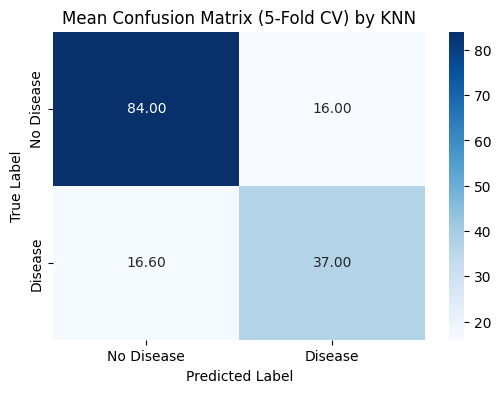

In [ ]:
# Confusion Matrix
mean_conf_matrix = np.mean(conf_matrices, axis=0)
plt.figure(figsize=(6, 4))
sns.heatmap(mean_conf_matrix, annot=True, fmt=".2f", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Mean Confusion Matrix (5-Fold CV) by KNN")
plt.show()

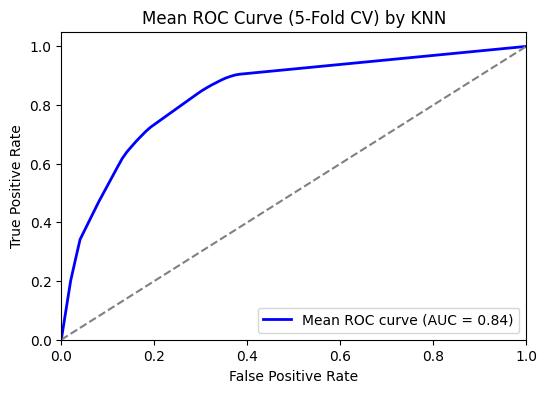

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(all_fpr, mean_tpr, color="blue", lw=2, label=f"Mean ROC curve (AUC = {mean_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # เส้นไดอากอนอล
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Mean ROC Curve (5-Fold CV) by KNN")
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
DecisionTreeClassifier()

DecisionTreeClassifier()

In [ ]:
#step 1 แยก features(X) และ target(y)
X = data.drop(columns=["Outcome"])
y = data["Outcome"]

In [ ]:
#step 2  training and testing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=80)
# model  Standardization  SVM, KNN, Logistic Regression
# Standardization  >> Tree-based models (Decision Tree, Random Forest, XGBoost, LightGBM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#step 3 fit model
dt = DecisionTreeClassifier(criterion = 'log_loss',random_state=0, max_depth = 3)
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='log_loss', max_depth=3, random_state=0)

In [ ]:
dt_predict = dt.predict(X_test)
dt_predict

array([0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0])

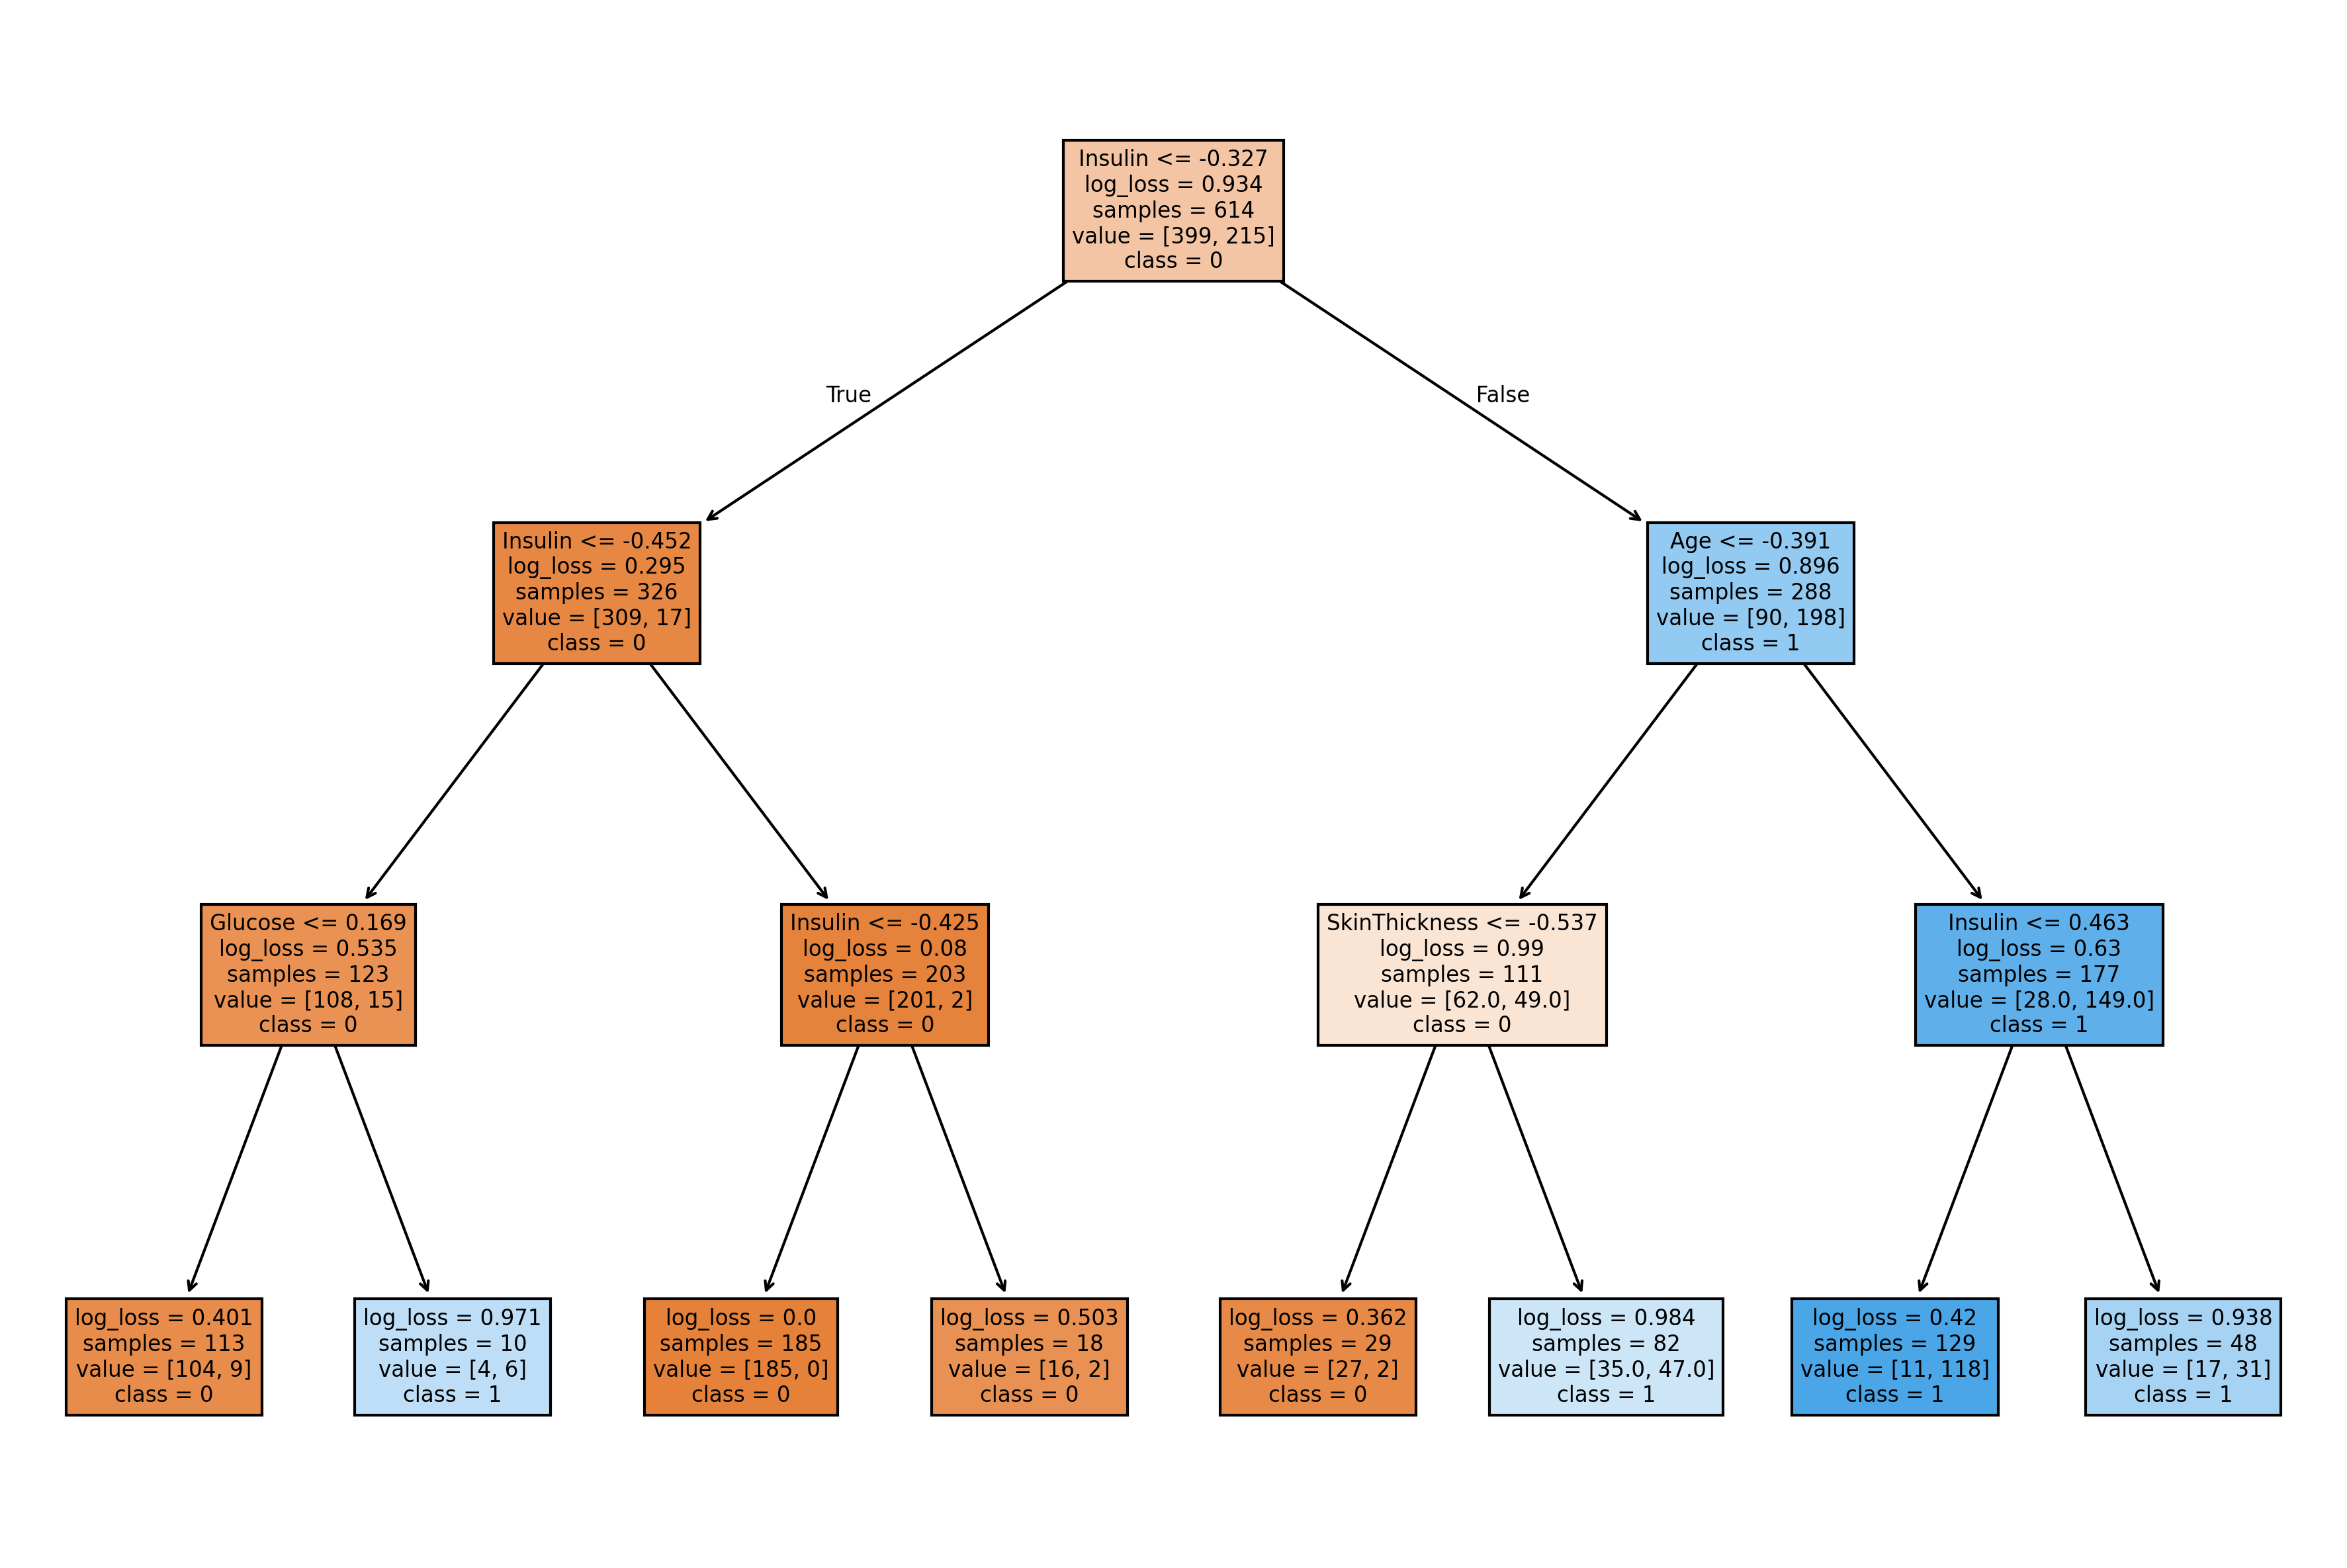

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

class_names = [str(c) for c in set(y)]

plt.figure(figsize=(15, 10),dpi=300)
plot_tree(dt, feature_names=data.columns[:-1], class_names=class_names, filled=True)
plt.show()

In [ ]:
pred_5 =dt.predict(X_test[150:])
print(pred_5)

[1 0 1 0]


In [ ]:
real_5 = np.array(y_test[150:])
print(real_5)

[0 0 0 0]


In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,classification_report,ConfusionMatrixDisplay

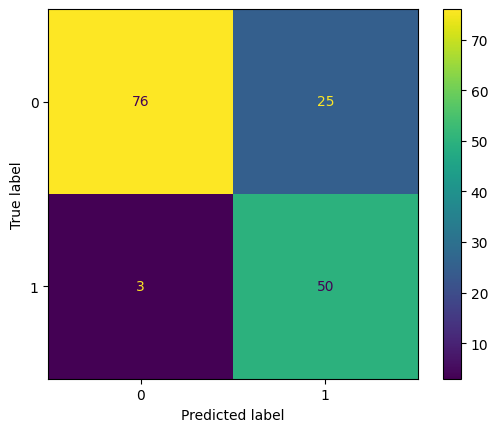

In [ ]:
dt_conf_matrix = confusion_matrix(y_test, dt_predict)
ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test)

In [ ]:
dt_acc = dt.score(X_test, y_test)

In [ ]:
print("Confussion matrix") # Confusion Matrix
print(dt_conf_matrix, "\n")
print("Accuracy of DecisionTreeClassifier:",dt_acc*100,'\n') # Accuracy
print(classification_report(y_test,dt_predict))

Confussion matrix
[[76 25]
 [ 3 50]] 

Accuracy of DecisionTreeClassifier: 81.81818181818183 

              precision    recall  f1-score   support

           0       0.96      0.75      0.84       101
           1       0.67      0.94      0.78        53

    accuracy                           0.82       154
   macro avg       0.81      0.85      0.81       154
weighted avg       0.86      0.82      0.82       154



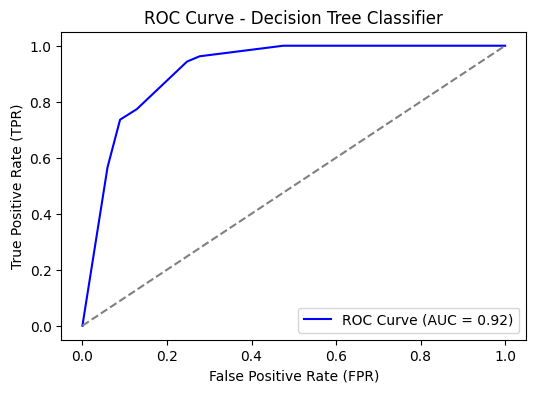

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

#  (probability) class 1
dt_prob = dt.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, dt_prob)
roc_auc = auc(fpr, tpr)  # AUC (Area Under the Curve)

#  ROC Curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # เส้นไดอะกอนอล
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - Decision Tree Classifier")
plt.legend(loc="lower right")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
import warnings

warnings.filterwarnings('ignore')

In [ ]:
categorical = [var for var in data.columns if data[var].dtype=='O']

print('There are {} categorical variables\n'.format(len(categorical)))

print('The categorical variables are :\n\n', categorical)

There are 0 categorical variables

The categorical variables are :

 []


In [ ]:
numerical = [var for var in data.columns if data[var].dtype!='O']

print('There are {} numerical variables\n'.format(len(numerical)))

print('The numerical variables are :', numerical)

There are 9 numerical variables

The numerical variables are : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [ ]:
data[numerical].head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [ ]:
#  Feature Vector (X)  Target Variable (y)
X = data.drop(['Outcome'], axis=1)  #  'Outcome'  Features
y = data['Outcome']  # 'Outcome'

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 100)

In [ ]:
X_train.shape, X_test.shape

((614, 8), (154, 8))

In [ ]:
X_train.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,float64
SkinThickness,int64
Insulin,float64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64


In [ ]:
categorical = [col for col in X_train.columns if X_train[col].dtypes == 'O']

categorical

[]

In [ ]:
numerical = [col for col in X_train.columns if X_train[col].dtypes != 'O']

numerical

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [ ]:
X_train[categorical].isnull().mean()

,0


In [ ]:
for col in categorical:
    if X_train[col].isnull().mean()>0:
        print(col, (X_train[col].isnull().mean()))

In [ ]:
X_test[categorical].isnull().sum()

,0


In [ ]:
print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
X_train.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0


In [ ]:
X_test.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0


In [ ]:
cols = X_train.columns

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train) #fit IQR

X_test = scaler.transform(X_test)

In [ ]:
X_train = pd.DataFrame(X_train, columns=[cols])

In [ ]:
X_test = pd.DataFrame(X_test, columns=[cols])

In [ ]:
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1.4,1.104294,0.7500,-0.142857,0.000000,-0.429752,-0.479153,1.5625
1,0.2,0.711656,0.8125,-0.142857,-0.037313,-0.297521,-0.460622,-0.1250
2,-0.2,-0.171779,0.1250,0.142857,0.335821,0.088154,0.886830,-0.1250
3,0.4,-0.122699,-0.3750,0.571429,1.000000,0.683196,-0.270020,0.7500
4,1.4,0.294479,-0.6250,1.142857,1.000000,1.057851,0.206486,0.5625


In [ ]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

# fit the model
gnb.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred_test = gnb.predict(X_test)

In [ ]:
y_pred_test[:10]

array([0, 0, 1, 0, 1, 1, 1, 0, 1, 0])

In [ ]:
from sklearn.metrics import accuracy_score
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_test)))

Model accuracy score: 0.6883


In [ ]:
y_pred_train = gnb.predict(X_train)

#  Training Set
y_pred_train[:10]

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [ ]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

Training-set accuracy score: 0.7883


In [ ]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(gnb.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(gnb.score(X_test, y_test)))

Training set score: 0.7883
Test set score: 0.6883


In [ ]:
#Print Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

print('Confusion matrix\n\n', cm)

print('\nTrue Positives(TP) = ', cm[0,0])

print('\nTrue Negatives(TN) = ', cm[1,1])

print('\nFalse Positives(FP) = ', cm[0,1])

print('\nFalse Negatives(FN) = ', cm[1,0])

Confusion matrix

 [[79 22]
 [26 27]]

True Positives(TP) =  79

True Negatives(TN) =  27

False Positives(FP) =  22

False Negatives(FN) =  26


<Axes: >

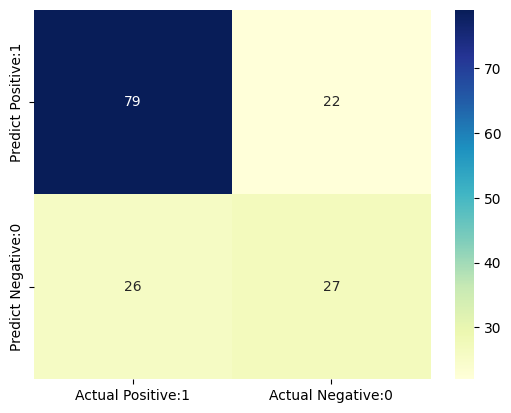

In [ ]:
cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'],
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

In [ ]:

y_pred_prob = gnb.predict_proba(X_test)[0:10]

y_pred_prob

array([[9.46080720e-01, 5.39192801e-02],
       [9.84686081e-01, 1.53139187e-02],
       [3.69435401e-02, 9.63056460e-01],
       [9.65764866e-01, 3.42351338e-02],
       [4.50353135e-01, 5.49646865e-01],
       [1.43422149e-01, 8.56577851e-01],
       [2.61782365e-04, 9.99738218e-01],
       [9.75906388e-01, 2.40936119e-02],
       [3.36955023e-03, 9.96630450e-01],
       [9.79773290e-01, 2.02267098e-02]])

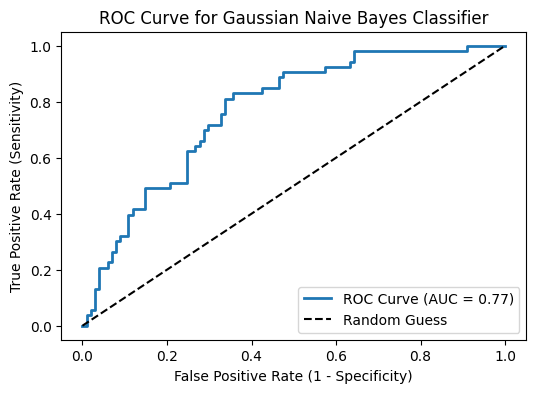

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

#  Class 1 (Positive Class)
y_prob_test = gnb.predict_proba(X_test)[:, 1]  #  Class 1

#  ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)  #  AUC

#  ROC Curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

#
plt.title('ROC Curve for Gaussian Naive Bayes Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend()
plt.show()

In [ ]:
import numpy as np

# Example values for a person
# [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]
person_data = [2, 120, 70, 25, 80, 32.0, 0.5, 30]

# Convert to numpy array and reshape for model
input_data = np.array(person_data).reshape(1, -1)

# Predict using your trained model
prediction = model.predict(input_data)

# Show the result
if prediction[0] == 1:
    print("⚠️ The person is likely to have diabetes.")
else:
    print("✅ The person is not likely to have diabetes.")

✅ The person is not likely to have diabetes.
